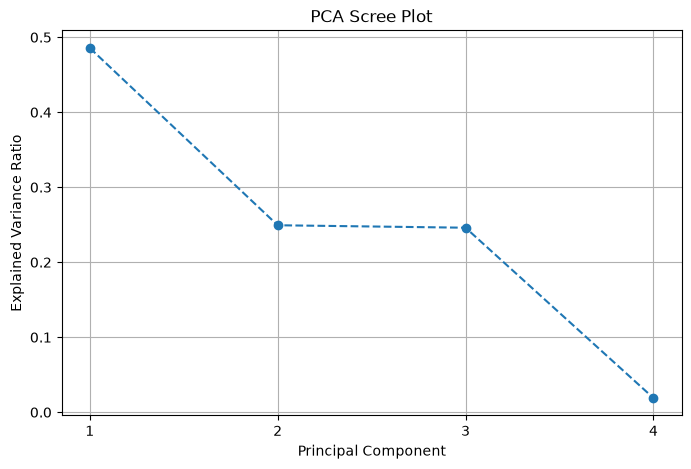

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('retail_sales_dataset.csv')
df_clean = df.dropna(subset=['Age', 'Quantity', 'Price per Unit', 'Total Amount'])

features = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()
plt.show()

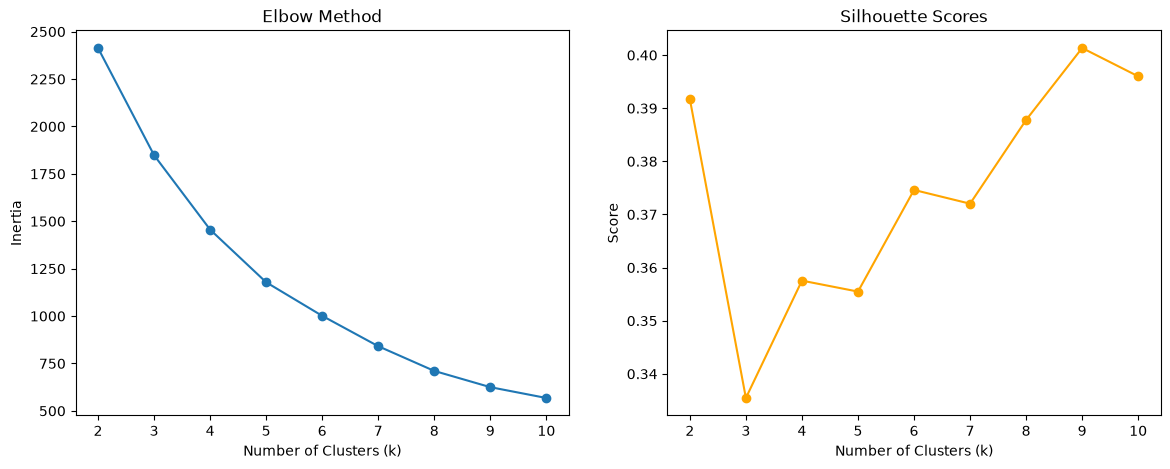

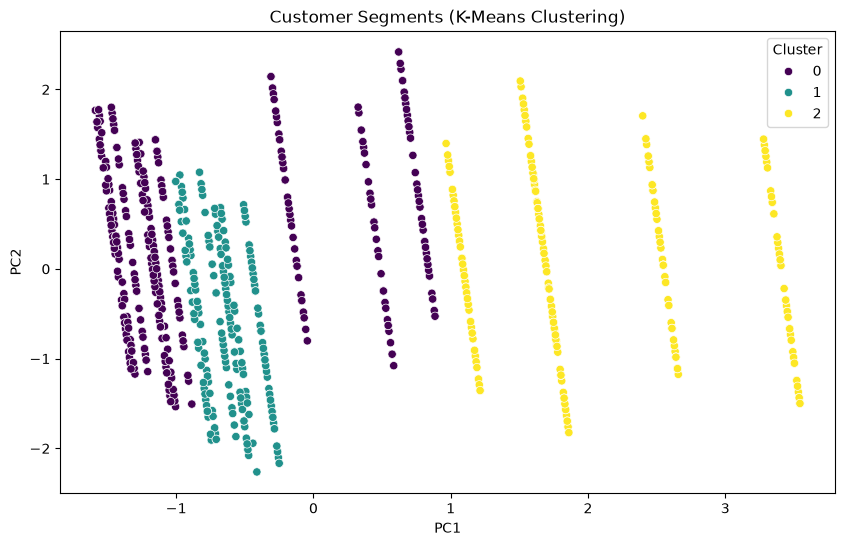

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K, inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K, sil_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')
plt.show()

optimal_k = 3 
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = final_kmeans.fit_predict(X_scaled)

pca_2d = PCA(n_components=2)
components = pca_2d.fit_transform(X_scaled)
df_clean['PC1'] = components[:, 0]
df_clean['PC2'] = components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_clean, palette='viridis')
plt.title('Customer Segments (K-Means Clustering)')
plt.show()